In [ ]:
#import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from FEM_functions import *
import time

In [ ]:
#def assemble_K_sinus(N, a_func):
#    """Stivhedsmatrix for sinusbasis med generel a(x)."""
#    K = np.zeros((N, N))
#    x = np.linspace(0, 1, 1000)
#    for k in range(1, N + 1):
#        dpsi_k = np.cos(k*np.pi*x)*k*np.pi  # den afledede af sin(k*pi*x)
#        for l in range(1, N + 1):
#            dpsi_l = np.cos(l*np.pi*x)*l*np.pi  # den afledede af sin(l*pi*x)
#            K[k-1, l-1] = np.trapz(a_func(x)*dpsi_k*dpsi_l,x)  # integrer a(x)*dpsi_k*dpsi_l med np.trapezoid
#    return K

#def assemble_p_sinus(N, p_func):
#    """Lastvektor for sinusbasis med generel p(x)."""
#    x = np.linspace(0, 1, 1000)
#    p_vec = np.zeros(N)
#    for k in range(1, N + 1):
#        psi_k = np.sin(k*np.pi*x)  # beregn psi_k = sin(k*pi*x)
#        p_vec[k-1] = np.trapz(p_func(x)*psi_k,x)  # integrer p(x)*psi_k med np.trapezoid
#    return p_vec

a_func = lambda x: np.where(x < 0.5, 2.0, 1.0)  # definer a(x) med np.where
np.piecewise(x, [])
p_func = lambda x: np.where((x >= 2/5) & x < 3/5, 20, 0)  # definer p(x) med np.where

In [77]:
# (a) Saml K og p for N = 10
N = 10
K_sin = assemble_K_sinus(N, a_func)
p_sin = assemble_p_sinus(N, p_func)

# undersøg K, f.eks. med plt.spy eller print
print(K_sin)
print(np.vstack(p_sin))

TypeError: ufunc 'bitwise_and' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

[[ 5.37251387e-01]
 [-1.44271792e-02]
 [-5.11732746e-02]
 [ 6.44363867e-03]
 [ 1.29845516e-02]
 [-3.51427580e-03]
 [-3.25312256e-03]
 [ 1.90564132e-03]
 [-1.45228027e-05]
 [-7.58811918e-04]]
u hat <class 'numpy.ndarray'> 200 [0.00000000e+00 6.46107067e-03 1.29244595e-02 1.93924247e-02
 2.58671068e-02 3.23504727e-02 3.88442655e-02 4.53499590e-02
 5.18687199e-02 5.84013768e-02 6.49483994e-02 7.15098850e-02
 7.80855562e-02 8.46747671e-02 9.12765194e-02 9.78894872e-02
 1.04512051e-01 1.11142337e-01 1.17778266e-01 1.24417607e-01
 1.31058031e-01 1.37697170e-01 1.44332683e-01 1.50962307e-01
 1.57583921e-01 1.64195598e-01 1.70795654e-01 1.77382692e-01
 1.83955636e-01 1.90513764e-01 1.97056722e-01 2.03584537e-01
 2.10097616e-01 2.16596741e-01 2.23083047e-01 2.29557998e-01
 2.36023351e-01 2.42481115e-01 2.48933506e-01 2.55382890e-01
 2.61831730e-01 2.68282528e-01 2.74737766e-01 2.81199846e-01
 2.87671038e-01 2.94153426e-01 3.00648857e-01 3.07158906e-01
 3.13684834e-01 3.20227562e-01 3.26787653e-

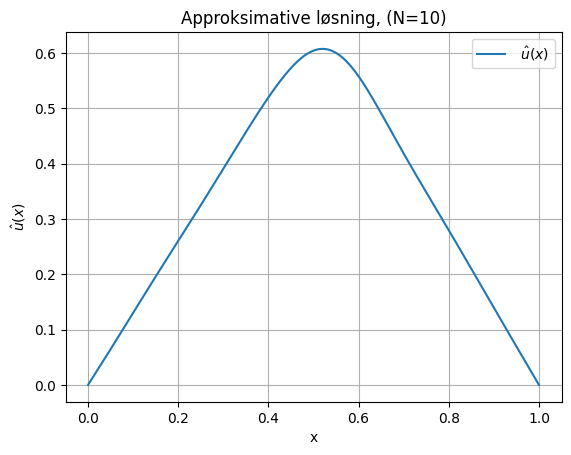

In [8]:
# (b) Løs systemet og plot løsningen
# løs K*u = p og plot u_hat(x) = sum u_k*sin(k*pi*x)
u=np.linalg.solve(K_sin, p_sin)
print(np.vstack(u))

x_plot = np.linspace(0, 1, 200)
u_hat = np.zeros_like(x_plot)

for k in range(1, N + 1):
    u_hat += u[k-1] * np.sin(k * np.pi * x_plot)

print("u hat", type(u_hat), len(u_hat), u_hat)

# Plot den eksakte løsning u = 0.5*x*(1-x) hvis a=1, p=1
plt.figure()
plt.plot(x_plot, u_hat, label=r' $\hat{u}(x)$')
plt.xlabel('x')
plt.ylabel(r'$\hat{u}(x)$')
plt.legend()
plt.grid(True)
plt.title(f"Approksimative løsning, (N={N})")
plt.show()

In [ ]:
#c: mål beregningstiden for at samle k og p med sinusbasis for N= 10,50,100,200. Hvad er K’s størrelse, og hvor mange ikke-nul indgange har den?

#N=10
none_zero=0
# (a) Saml K og p for N = 10
N = 10
start_time=time.time()
K_sin = assemble_K_sinus(N, a_func)
p_sin = assemble_p_sinus(N, p_func)
print(f"Beregningstid: {time.time()-start_time}s")

#K's størrelse og ikke nul ingange
print(f"dimensioner af matrix:{K_sin.shape}")
for row in K_sin:
    for col in row:
        if col != 0:
            none_zero+=1
print(f"ikke-nul indgange: {none_zero}")

Beregningstid: 0.003513336181640625s
dimensioner af matrix:(10, 10)
ikke-nul indgange: 100


In [ ]:
#N=50
none_zero=0
# (a) Saml K og p for N = 10
N = 50
start_time=time.time()
K_sin = assemble_K_sinus(N, a_func)
p_sin = assemble_p_sinus(N, p_func)
print(f"Beregningstid: {time.time()-start_time}s")

#K's størrelse og ikke nul ingange
print(f"dimensioner af matrix:{K_sin.shape}")
for row in K_sin:
    for col in row:
        if col != 0:
            none_zero+=1
print(f"ikke-nul indgange: {none_zero}")

Beregningstid: 0.06711864471435547s
dimensioner af matrix:(50, 50)
ikke-nul indgange: 2490


In [ ]:
#N=100
none_zero=0
# (a) Saml K og p for N = 10
N = 100
start_time=time.time()
K_sin = assemble_K_sinus(N, a_func)
p_sin = assemble_p_sinus(N, p_func)
print(f"Beregningstid: {time.time()-start_time}s")

#K's størrelse og ikke nul ingange
print(f"dimensioner af matrix:{K_sin.shape}")
for row in K_sin:
    for col in row:
        if col != 0:
            none_zero+=1
print(f"ikke-nul indgange: {none_zero}")

Beregningstid: 0.2505524158477783s
dimensioner af matrix:(100, 100)
ikke-nul indgange: 9984


In [ ]:
#N=200
none_zero=0
# (a) Saml K og p for N = 10
N = 200
start_time=time.time()
K_sin = assemble_K_sinus(N, a_func)
p_sin = assemble_p_sinus(N, p_func)
print(f"Beregningstid: {time.time()-start_time}s")

#K's størrelse og ikke nul ingange
print(f"dimensioner af matrix:{K_sin.shape}")
for row in K_sin:
    for col in row:
        if col != 0:
            none_zero+=1
print(f"ikke-nul indgange: {none_zero}")

Beregningstid: 0.9727520942687988s
dimensioner af matrix:(200, 200)
ikke-nul indgange: 39958
